In [1]:
import shap
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split

In [26]:
# Load the dataset
data = pd.read_csv("C:/Users/kpuni/Downloads/healthcare_dataset.csv (3)/healthcare_dataset.csv")  # Replace with your dataset path


In [27]:
data

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [3]:
print(data.columns)


Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')


In [5]:
# Create a target column (e.g., anomalies based on billing amount)
data['target'] = (data['Billing Amount'] > 30000).astype(int)  # Example rule
target_column = 'target'

In [6]:
target_column = 'Test Results'

In [7]:
X = data.drop(columns=[target_column])
y = data[target_column]

In [8]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(X.columns)

Index(['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission',
       'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount',
       'Room Number', 'Admission Type', 'Discharge Date', 'Medication',
       'target'],
      dtype='object')


In [12]:
categorical_columns = ['Gender', 'Blood Type', 'Medical Condition']  # Update as needed

In [13]:
for col in categorical_columns:
    if col in X.columns:  # Check if column exists
        X[col] = encoder.fit_transform(X[col])

In [15]:
from sklearn.preprocessing import LabelEncoder

for col in X.columns:
    if X[col].dtype == 'object':
        encoder = LabelEncoder()
        X[col] = encoder.fit_transform(X[col])


In [16]:
print(X.dtypes)


Age                     int64
Gender                  int64
Blood Type              int64
Medical Condition       int64
Date of Admission     float64
Doctor                float64
Hospital              float64
Insurance Provider    float64
Billing Amount        float64
Room Number             int64
Admission Type        float64
Discharge Date        float64
Medication            float64
target                  int64
dtype: object


In [17]:
irrelevant_columns = ['Date of Admission', 'Discharge Date', 'Doctor', 'Hospital', 'Medication']
X = X.drop(columns=irrelevant_columns, errors='ignore')


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [19]:
model = IsolationForest(random_state=42)
model.fit(X_scaled)


IsolationForest(random_state=42)

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest

# Drop irrelevant columns
irrelevant_columns = ['Date of Admission', 'Discharge Date', 'Doctor', 'Hospital', 'Medication']
X = X.drop(columns=irrelevant_columns, errors='ignore')

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the Isolation Forest model
model = IsolationForest(random_state=42)
model.fit(X_scaled)


IsolationForest(random_state=42)

In [21]:
# Make predictions
predictions = model.predict(X_scaled)

In [22]:
# Add predictions to the original dataset
X['Anomaly'] = predictions

# Count anomalies
anomalies_count = (predictions == -1).sum()
print(f"Total anomalies detected: {anomalies_count}")

Total anomalies detected: 50602


In [23]:
# Filter anomalies
anomalies = X[predictions == -1]

# Display a sample of anomalies
print("Sample anomalies:")
print(anomalies.head())

Sample anomalies:
   Age  Gender  Blood Type  Medical Condition  Insurance Provider  \
1   62       1           0                  5                 0.0   
2   76       0           1                  5                 0.0   
3   28       0           6                  3                 0.0   
4   43       0           2                  2                 0.0   
5   36       1           0                  1                 0.0   

   Billing Amount  Room Number  Admission Type  target  Anomaly  
1    33643.327287          265             0.0       1       -1  
2    27955.096079          205             0.0       0       -1  
3    37909.782410          450             0.0       1       -1  
4    14238.317814          458             0.0       0       -1  
5    48145.110951          389             0.0       1       -1  


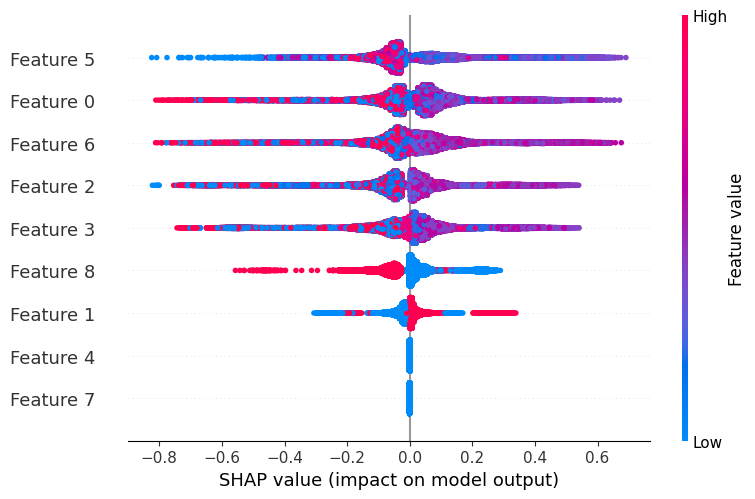

In [28]:
shap.summary_plot(shap_values, X_scaled)


In [29]:
shap.summary_plot(shap_values[:, :-1], X_scaled)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [30]:
print("shap_values shape:", shap_values.shape)
print("X_scaled shape:", X_scaled.shape)

shap_values shape: (55500, 9)
X_scaled shape: (55500, 9)


In [32]:
import pandas as pd

# Convert X_scaled to DataFrame if it's not already
if not isinstance(X_scaled, pd.DataFrame):
    feature_names = [f"Feature {i}" for i in range(X_scaled.shape[1])]  # Replace with actual names if available
    X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

In [33]:
explainer = shap.Explainer(model, X_scaled)
shap_values = explainer(X_scaled)

100%|===================| 55471/55500 [20:18<00:00]        

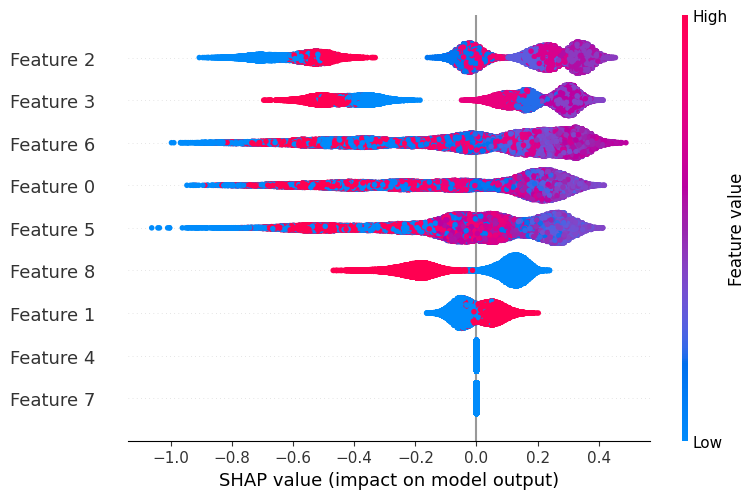

In [34]:
shap.summary_plot(shap_values, X_scaled)

In [35]:
# Visualize explanation for a single prediction
shap.force_plot(explainer.expected_value[1], shap_values[1], X_test_scaled[1])

IndexError: invalid index to scalar variable.